In [1]:
import pandas as pd
import json

df = pd.read_csv("../dataset_comparative_2020_2026/comparative_files/keywords_yake_meta.csv")
print(f"Документів: {len(df):,}")
print(df.columns.tolist())
df.head(100)

Документів: 8,427
['doc_id', 'length', 'rubric', 'outcome', 'num_stages', 'main_committee', 'card_id', 'reg_num', 'reg_date', 'keywords_yake', 'num_keywords']


,doc_id,length,rubric,outcome,num_stages,main_committee,card_id,reg_num,reg_date,keywords_yake,num_keywords
0,12273_Порівняльна таблиця (04.12.2024),172,Економічна політика,rejected,5,Підласа Р. А. Комітет Верховної Ради України з...,45350,12273,2024-12-02,"[""Державний бюджет"", ""ПОРІВНЯЛЬНА ТАБЛИЦЯ"", ""В...",5
1,12272_Порівняльна таблиця (04.12.2024),376,Економічна політика,in_progress,4,Підласа Р. А. Комітет Верховної Ради України з...,45328,12272,2024-12-02,"[""Автономної Республіки"", ""Республіки Крим"", ""...",5
2,12274_Порівняльна таблиця (03.12.2024),145,Економічна політика,rejected,5,Підласа Р. А. Комітет Верховної Ради України з...,45349,12274,2024-12-02,"[""Державний бюджет"", ""ПОРІВНЯЛЬНА ТАБЛИЦЯ"", ""В...",5
3,12275_Порівняльна таблиця (04.12.2024),476,Безпека і оборона,in_progress,4,Завітневич О. М. Комітет Верховної Ради Україн...,45341,12275,2024-12-02,"[""військову службу"", ""Закону України"", ""ПОРІВН...",5
4,12276_Порівняльна таблиця (04.12.2024),499,Економічна політика,in_progress,4,Гетманцев Д. О. Комітет Верховної Ради України...,45363,12276,2024-12-02,"[""ПОРІВНЯЛЬНА ТАБЛИЦЯ"", ""проекту Закону"", ""лік...",5
...,...,...,...,...,...,...,...,...,...,...,...
95,12367-3_Порівняльна таблиця (14.01.2025),2718,Правова політика,in_progress,7,Іонушас С. К. Комітет Верховної Ради України з...,55616,12367-3,2025-01-14,"[""досудового розслідування"", ""кримінального пр...",27
96,12367_Порівняльна таблиця (31.12.2024),2100,Правова політика,rejected,8,Іонушас С. К. Комітет Верховної Ради України з...,55533,12367,2024-12-30,"[""досудового розслідування"", ""кодексу"", ""ПОРІВ...",21
97,12368-1_Порівняльна таблиця (07.01.2025),3852,Правова політика,in_progress,20,Маслов Д. В. Комітет Верховної Ради України з ...,55553,12368-1,2025-01-07,"[""України"", ""суду"", ""адміністративного суду"", ...",38
98,12353_Порівняльна таблиця (Друге читання),27351,Галузевий розвиток,in_progress,16,Бондаренко О. В. Комітет Верховної Ради Україн...,55504,12353,2024-12-23,"[""Міністрів України"", ""Кабінетом Міністрів"", ""...",50


In [2]:
from collections import Counter

all_kw = []
for kw_json in df["keywords_yake"]:
    try:
        kw_list = json.loads(kw_json)
        all_kw.extend([kw.lower().strip() for kw in kw_list])
    except:
        pass

counter = Counter(all_kw)
print(f"Унікальних KW: {len(counter):,}")
print(f"Всього KW: {len(all_kw):,}")
print(f"\nТоп-30 найчастіших:")
for kw, cnt in counter.most_common(30):
    print(f"  {cnt:>5}  {kw}")

Унікальних KW: 18,018
Всього KW: 176,349

Топ-30 найчастіших:
   5948  порівняльна таблиця
   5009  україни
   4465  закону україни
   2456  міністрів україни
   2006  ради україни
   1947  зміст положення
   1944  стаття
   1825  закону
   1674  верховної ради
   1551  законом україни
   1426  закон україни
   1240  чинна редакція
   1129  кабінетом міністрів
   1079  статті
   1005  кодексу україни
    881  проекту закону
    864  відомості верховної
    847  проекту висновки
    822  обґрунтування законопроект
    821  законом
    818  читанні пропозиції
    786  редакція
    774  пропозиції
    766  висновки
    742  законопроект
    722  редакція редакція
    694  законодавства зміст
    661  виконавчої влади
    644  осіб
    640  відхилено


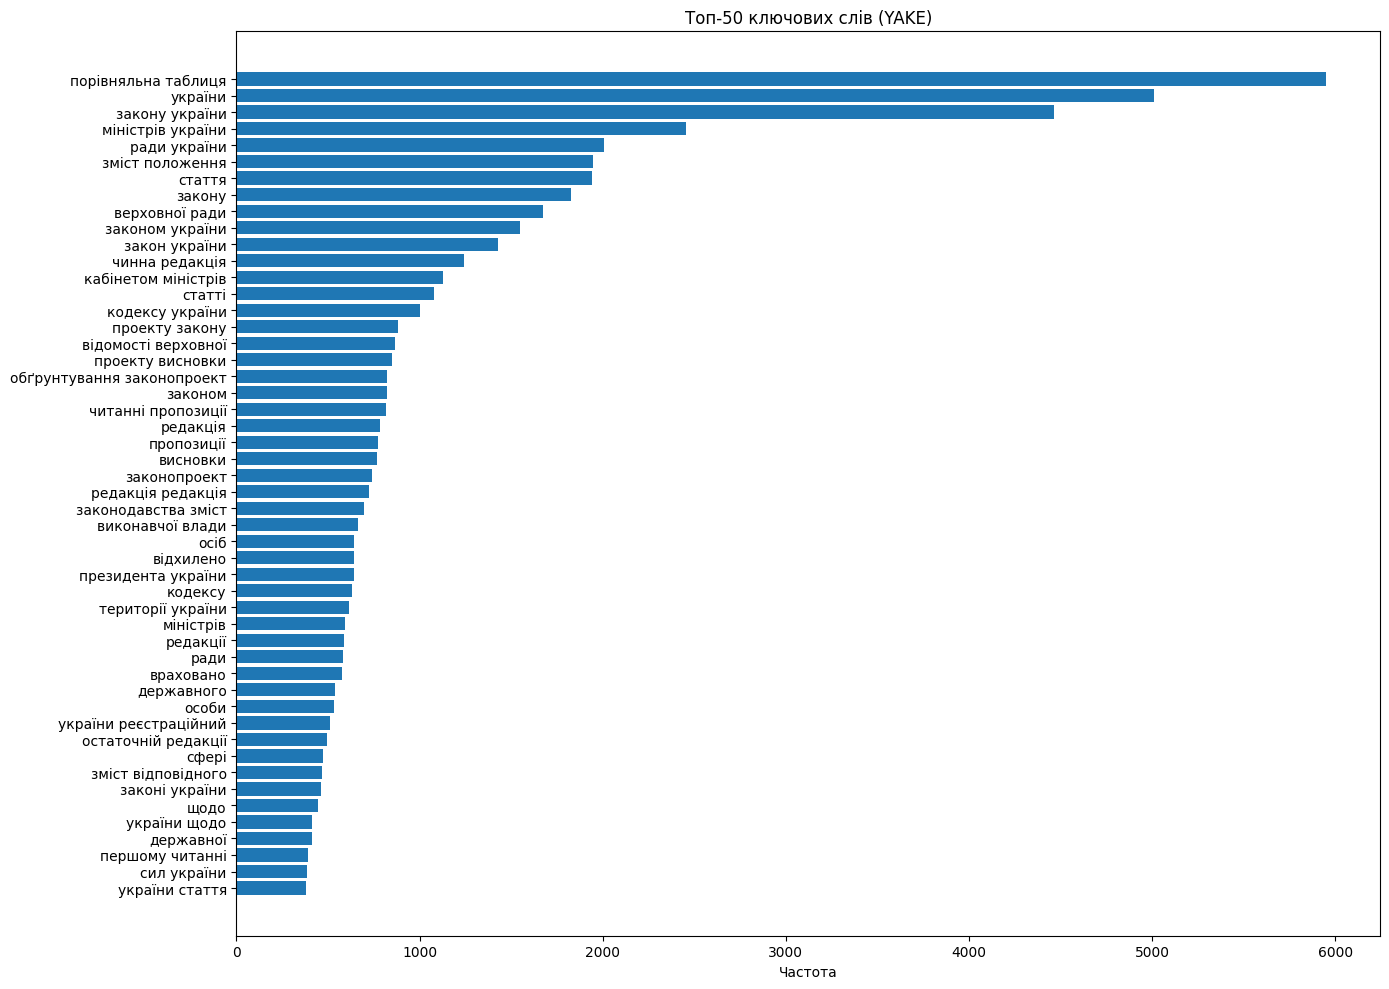

In [3]:
import matplotlib.pyplot as plt

top_50 = counter.most_common(50)
labels = [kw for kw, cnt in top_50]
values = [cnt for kw, cnt in top_50]

plt.figure(figsize=(14, 10))
plt.barh(labels[::-1], values[::-1])
plt.xlabel("Частота")
plt.title("Топ-50 ключових слів (YAKE)")
plt.tight_layout()
plt.show()

In [4]:
print("Топ-10 KW по рубриках:\n")
for rubric, group in df.groupby("rubric"):
    kw_rubric = []
    for kw_json in group["keywords_yake"]:
        try:
            kw_rubric.extend(json.loads(kw_json))
        except:
            pass
    top = Counter([k.lower() for k in kw_rubric]).most_common(5)
    print(f"{rubric}:")
    for kw, cnt in top:
        print(f"  {cnt:>4}  {kw}")
    print()

Топ-10 KW по рубриках:

Безпека і оборона:
   394  закону україни
   384  порівняльна таблиця
   375  україни
   178  міністрів україни
   171  сил україни

Галузевий розвиток:
  1176  порівняльна таблиця
  1158  україни
  1020  закону україни
   807  міністрів україни
   541  стаття

Гуманітарна політика:
   234  порівняльна таблиця
   148  україни
   148  закону україни
    98  зміст положення
    86  міністрів україни

Державне будівництво:
   344  порівняльна таблиця
   318  україни
   268  закону україни
   226  ради україни
   216  верховної ради

Економічна політика:
  1640  порівняльна таблиця
  1489  україни
  1278  закону україни
   652  міністрів україни
   598  зміст положення

Організаційні питання:
    43  верховної ради
    42  ради україни
    21  слуга народу
    20  постанови верховної
    18  політичної партії

Правова політика:
  1621  порівняльна таблиця
  1100  україни
   910  закону україни
   553  стаття
   494  ради україни

Соціальна політика:
   535  порівнял

In [11]:
# Слова які не несуть змісту і треба буде відфільтрувати
STOPWORDS = [
    "порівняльна таблиця", "верховної ради", "відомості верховної",
    "закону україни", "стаття", "частина", "пункт", "абзац"
]

print("Потенційні стоп-слова у топ-100:")
for kw, cnt in counter.most_common(100):
    if any(s in kw for s in STOPWORDS):
        print(f"  {cnt:>5}  ⚠  {kw}")

Потенційні стоп-слова у топ-100:
   5948  ⚠  порівняльна таблиця
   4465  ⚠  закону україни
   1944  ⚠  стаття
   1674  ⚠  верховної ради
    864  ⚠  відомості верховної
    381  ⚠  україни стаття
    279  ⚠  пункту
    271  ⚠  відхилено абзац


In [15]:


STOPWORDS = {
    "порівняльна таблиця", "верховної ради", "відомості верховної",
    "закону україни", "стаття", "частина", "пункт", "абзац"
}

STOPWORDS.update({
    # артефакти порівняльних таблиць
    "порівняльна таблиця", "відомості верховної", "зміст положення",
    "чинна редакція", "редакція", "редакції", "редакція редакція",
    "проекту висновки", "обґрунтування законопроект",
    "читанні пропозиції", "остаточній редакції", "такій редакції",
    "зміст відповідного", "запропонований головним", "головним комітетом",
    "реалізує державну", "відхилено абзац", "першому читанні",
    "україни реєстраційний", "україни щодо", "україни стаття",
    "відсутня стаття", "такого змісту", "враховано частково",
    "відхилено пункт", "перехідні положення", "проєкту закону",
    "органу виконавчої",
    # загальні юридичні
    "верховної ради", "закону україни", "закон україни", "законом україни",
    "законом", "закону", "законодавства зміст", "законів україни",
    "законі україни", "законами україни", "законопроект", "законодавства україни",
    "кодексу україни", "кодексом україни", "кодекс україни",
    "проекту закону", "проекту", "конституції україни",
    "радою україни", "ради україни", "рада україни",
    "верховної", "президента україни", "президентом україни",
    # структурні елементи
    "стаття", "статті", "статтею",
    "частина", "частини", "частину", "частиною",
    "пункт", "пункту", "пункти",
    "абзац", "абзацу", "абзац", "розділу",
    # процедурні/службові
    "пропозиції", "висновки", "враховано", "відхилено",
    "виконавчої", "виконавчої влади",
    "відповідно", "щодо", "зміст", "разі", "рішення",
    "головним комітетом",
    # загальні іменники без контексту
    "україни", "міністрів", "ради", "влади",
    "державного", "державної", "державну", "державний бюджет",
    "осіб", "особи", "органу", "органів",
    "сфері", "забезпечення", "строк", "майна",
    "провадження", "положення", "доходів",
    "національного", "національної", "засобів",
    "громадян", "послуг", "реєстру", "фонду",
    "охорони", "освіти", "вищої", "права", "право",
    "діяльності", "проведення", "порядку", "комісії",
    "кабінетом", "служби", "фонду державного",
    "єдиного", "такого",
    # географічні/політичні артефакти
    "республіки крим", "автономної республіки",
    "територію україни", "території україни",
    "російської федерації", "російської", "федерації",
})


def clean_keywords(kw_json: str) -> str:
    try:
        kw_list = json.loads(kw_json)
        filtered = [
            kw for kw in kw_list
            if kw.lower().strip() not in STOPWORDS
            and len(kw.strip()) > 3
            and not kw.strip().isdigit()
        ]
        return json.dumps(filtered, ensure_ascii=False)
    except:
        return kw_json


df["keywords_clean"] = df["keywords_yake"].apply(clean_keywords)
df["keywords_yake"] = df["keywords_clean"]
df.drop(columns=["keywords_clean"]).to_parquet(
    "../dataset_comparative_2020_2026/comparative_files/keywords_yake.parquet",
    index=False
)
print("Збережено!")

all_final = []
for kw_json in df["keywords_yake"]:
    try:
        all_final.extend(json.loads(kw_json))
    except:
        pass

counter_final = Counter([k.lower() for k in all_final])
print(f"Унікальних KW: {len(counter_final):,}")
print(f"\nФінальний топ-30:")
for kw, cnt in counter_final.most_common(30):
    print(f"  {cnt:>5}  {kw}")

Збережено!
Унікальних KW: 17,781

Фінальний топ-30:
   2456  міністрів україни
   1129  кабінетом міністрів
    630  кодексу
    385  сил україни
    371  кабінету міністрів
    312  безпеки україни
    305  бюджету україни
    272  державного бюджету
    262  оборони україни
    249  служби україни
    246  податку
    245  суду
    235  воєнного стану
    228  доходів громадян
    215  державну політику
    213  мінімумів доходів
    212  місцевого самоврядування
    200  збройних сил
    193  податкового кодексу
    192  військової служби
    182  адміністративні правопорушення
    179  україні
    177  неоподатковуваних мінімумів
    167  банку україни
    152  кабінет міністрів
    151  правопорушення
    148  військову службу
    146  кримінального кодексу
    145  суду україни
    144  безпеки


In [16]:
# Що робили: 
Завантажили keywords_yake_meta.csv з ключовими словами
Подивились топ-30 найчастіших KW
Побудували графік топ-50
Подивились KW по рубриках
Знайшли стоп-слова — службові юридичні слова що є в кожному документі і не несуть тематичного змісту (порівняльна таблиця, верховної ради, стаття тощо)
Відфільтрували їх → отримали keywords_clean

Навіщо це потрібно:
Якщо не фільтрувати — мережа документів буде побудована неправильно. Наприклад, порівняльна таблиця є у всіх 7541 документах → всі документи будуть з'єднані між собою через це слово → мережа буде суцільною кашею без структури.

SyntaxError: invalid character '—' (U+2014) (2506201719.py, line 6)

In [17]:
df["keywords_yake"] = df["keywords_clean"]
df.drop(columns=["keywords_clean"]).to_parquet(
    "../dataset_comparative_2020_2026/comparative_files/clean_keywords_yake.parquet",
    index=False
)
print("Збережено!")

Збережено!
